<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/Catboostbinaryclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
!pip install catboost

In [27]:
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [28]:
# load data
titanic=sns.load_dataset('titanic')
target='survived'

In [29]:
# top data
print(titanic.head())
print(titanic.isnull().sum())

   survived  pclass     sex   age  ...  deck  embark_town  alive  alone
0         0       3    male  22.0  ...   NaN  Southampton     no  False
1         1       1  female  38.0  ...     C    Cherbourg    yes  False
2         1       3  female  26.0  ...   NaN  Southampton    yes   True
3         1       1  female  35.0  ...     C  Southampton    yes  False
4         0       3    male  35.0  ...   NaN  Southampton     no   True

[5 rows x 15 columns]
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [30]:
# view the data of titanic
titanic.info()
print(titanic)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
     survived  pclass     sex   age  ...  deck  embark_town  alive  alone
0    

In [31]:
# preprocessing the data
categories = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'Unknown']
# filling missing value in deck column with a new category: Unknown
titanic['deck']=pd.Categorical(titanic['deck'],categories=categories,ordered=True)
titanic['deck']=titanic['deck'].fillna('Unknown')

# filling missing value in age column using mean imputation
age_mean=titanic['age'].fillna(0).mean()
titanic['age']=titanic['age'].fillna(age_mean)

# dropping missing values in embark as there are only two
titanic=titanic.dropna()

# dropping the alive columns to make a problem more challanges
titanic=titanic.drop('alive',axis=1)




In [32]:
# Create the feature matrix (X) and target vector (y)
X = titanic.drop(target, axis=1)
y = titanic[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [33]:
# model training
# specifying categorical features
categorical_features = ['sex', 'pclass', 'sibsp', 'parch', 'embarked',
                        'class', 'who', 'adult_male', 'embark_town', 'alone', 'deck']
#create and train the model
model = CatBoostClassifier(iterations=100, depth=8, learning_rate=0.1, cat_features=categorical_features,
                           loss_function='Logloss', custom_metric=['AUC'], random_seed=42)
model.fit(X_train, y_train)

0:	learn: 0.6571312	total: 53.5ms	remaining: 5.3s
1:	learn: 0.6221910	total: 56.8ms	remaining: 2.78s
2:	learn: 0.5939753	total: 58.5ms	remaining: 1.89s
3:	learn: 0.5702463	total: 63.6ms	remaining: 1.53s
4:	learn: 0.5494485	total: 64.8ms	remaining: 1.23s
5:	learn: 0.5318808	total: 68.4ms	remaining: 1.07s
6:	learn: 0.5166735	total: 73ms	remaining: 969ms
7:	learn: 0.5034372	total: 74.4ms	remaining: 856ms
8:	learn: 0.4912526	total: 78ms	remaining: 789ms
9:	learn: 0.4836415	total: 78.8ms	remaining: 709ms
10:	learn: 0.4743785	total: 83.3ms	remaining: 674ms
11:	learn: 0.4658533	total: 86.1ms	remaining: 632ms
12:	learn: 0.4581934	total: 87.1ms	remaining: 583ms
13:	learn: 0.4502682	total: 88.8ms	remaining: 546ms
14:	learn: 0.4447627	total: 89.6ms	remaining: 507ms
15:	learn: 0.4418242	total: 90.2ms	remaining: 474ms
16:	learn: 0.4361839	total: 93.9ms	remaining: 458ms
17:	learn: 0.4321366	total: 97.8ms	remaining: 446ms
18:	learn: 0.4272143	total: 99.8ms	remaining: 426ms
19:	learn: 0.4222480	total:

CatBoostClassifier(cat_features=['sex', 'pclass', 'sibsp', 'parch', 'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alone', 'deck'], custom_metric=['AUC'], depth=8, iterations=100, learning_rate=0.1, loss_function='Logloss', random_seed=42)

In [34]:
# Make Predection and Evaluate Model
y_pred=model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
# print accuracy
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.80


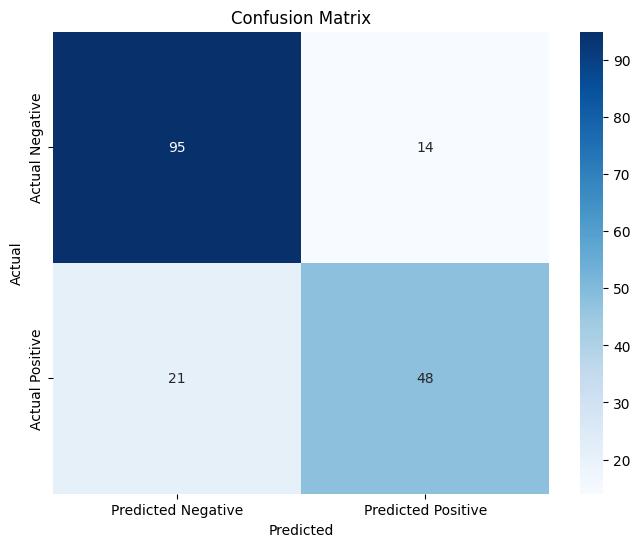

In [36]:
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm=confusion_matrix(y_test,y_pred)
# Plot Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[
            'Predicted Negative', 'Predicted Positive'], yticklabels=['Actual Negative', 'Actual Positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

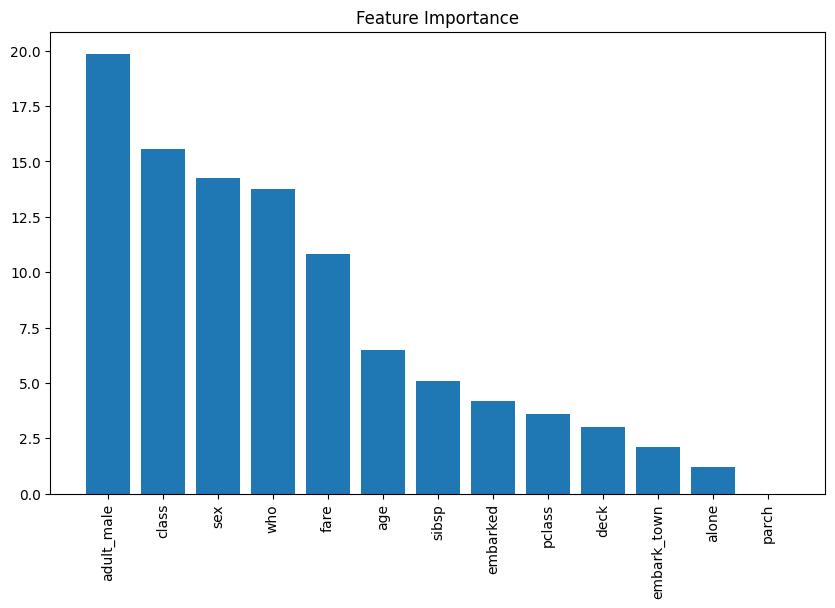

In [39]:
importances = model.get_feature_importance()
feature_names = X.columns
sorted_indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(feature_names)), importances[sorted_indices])
plt.xticks(range(len(feature_names)), feature_names[sorted_indices], rotation=90)
plt.title("Feature Importance")
plt.show()